# Wind Power Forecasting — Deep Learning Pipeline

End-to-end data preparation for LSTM and Transformer models.  
Loads the already-preprocessed parquet files from `data/`, applies DL-specific transformations,  
and produces ready-to-use PyTorch `DataLoader` objects.

**Pipeline steps**
1. Load data via `utils.load_data()`
2. Drop lag / rolling / delta / raw-direction / raw lat-lon features
3. Clip pathological outliers in `wind_shear` and `gust_factor`
4. Chronological train / val split (last 3 months of train as validation)
5. `StandardScaler` — fit on train sub-split only
6. Build sliding-window sequences per site → shape `(batch, lookback, features)`
7. PyTorch `WindDataset` + `DataLoader` objects

In [1]:
import sys
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sys.path.insert(0, str(Path('.')))
from utils import load_data, evaluate, plot_forecast

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Load Data

In [2]:
X_train, y_train, X_test, y_test, meta_train, meta_test, site_mapping = load_data()

X_train : (248304, 77)  |  X_test : (26390, 77)
Train period : 2023-01-01 → 2025-10-31
Test  period : 2025-11-01 → 2026-02-18
Sites : 10


## 2. Feature Selection — Drop Redundant Columns

Deep learning sequence models (LSTM, Transformer) receive the full lookback window of raw features  
at every step, making hand-crafted temporal features redundant:

| Dropped group | Columns | Reason |
|---|---|---|
| Raw wind direction (degrees) | `wind_direction_10m/100m` | Already encoded as sin/cos — circular discontinuity at 0°/360° |
| Raw coordinates | `latitude`, `longitude` | Redundant with `lat_rad`, `lon_rad` |
| Wind-speed lags | `ws*_lag*h` | The sequence context window already covers past timesteps |
| Rolling stats | `ws100_roll*` | The model learns its own temporal aggregation |
| Delta features | `ws100_delta*` | Rate-of-change is captured implicitly from adjacent steps |

> **Lead features are kept** (`ws100_lead1h`, `pres_lead*h`, etc.) — these are NWP forecast values  
> that are operationally available at inference time and are physically informative.

In [3]:
COLS_TO_DROP = [
    # Raw wind direction — sin/cos encodings already present
    'wind_direction_10m', 'wind_direction_100m',
    # Raw coordinates — radian versions already present
    'latitude', 'longitude',
    # Lag features — sequence window provides full temporal context
    'ws100_lag1h', 'ws100_lag2h', 'ws100_lag3h', 'ws100_lag6h',
    'ws10_lag1h',  'ws10_lag3h',  'ws10_lag6h',
    'gusts_lag1h', 'gusts_lag3h', 'gusts_lag6h',
    'pres_lag3h',  'pres_lag6h',
    # Rolling statistics — redundant with the sequence
    'ws100_roll3h_mean', 'ws100_roll3h_std',
    'ws100_roll6h_mean', 'ws100_roll6h_std',
    # Rate-of-change deltas — model captures these from adjacent steps
    'ws100_delta1h', 'ws100_delta3h', 'ws100_delta6h',
]

X_tr = X_train.drop(columns=COLS_TO_DROP)
X_te = X_test.drop(columns=COLS_TO_DROP)

N_FEATURES    = X_tr.shape[1]
FEATURE_NAMES = list(X_tr.columns)

print(f'Features dropped : {len(COLS_TO_DROP)}')
print(f'Features kept    : {N_FEATURES}')
print(f'\nRemaining features:')
for i, c in enumerate(FEATURE_NAMES):
    print(f'  [{i:2d}] {c}')

Features dropped : 23
Features kept    : 54

Remaining features:
  [ 0] wind_speed_10m
  [ 1] wind_speed_100m
  [ 2] wind_gusts_10m
  [ 3] temperature_2m
  [ 4] dewpoint_2m
  [ 5] apparent_temperature
  [ 6] pressure_msl
  [ 7] precipitation
  [ 8] cloud_cover
  [ 9] cloud_cover_low
  [10] cloud_cover_mid
  [11] cloud_cover_high
  [12] shortwave_radiation
  [13] direct_radiation
  [14] diffuse_radiation
  [15] weather_code
  [16] sunshine_duration
  [17] hour_sin
  [18] hour_cos
  [19] month_sin
  [20] month_cos
  [21] ws_10_sq
  [22] ws_10_cubed
  [23] wd_10_sin
  [24] wd_10_cos
  [25] u_10
  [26] v_10
  [27] ws_100_sq
  [28] ws_100_cubed
  [29] wd_100_sin
  [30] wd_100_cos
  [31] u_100
  [32] v_100
  [33] wind_shear
  [34] gust_factor
  [35] ws100_x_wd_cos
  [36] ws100_x_wd_sin
  [37] temp_dewpoint_delta
  [38] air_density_proxy
  [39] effective_wind_power
  [40] ws100_lead1h
  [41] ws100_lead2h
  [42] ws100_lead3h
  [43] ws100_lead6h
  [44] ws10_lead1h
  [45] ws10_lead3h
  [46] ws10

## 3. Clip Pathological Outliers

`wind_shear = wind_speed_100m / (wind_speed_10m + ε)` and  
`gust_factor = wind_gusts_10m / (wind_speed_10m + ε)` blow up when `wind_speed_10m ≈ 0`.  
Without clipping, the scaler maps these extreme values to tens of thousands of standard deviations,  
causing gradient explosion from the very first forward pass.

| Feature | Observed max (train) | Physical cap | Justification |
|---|---|---|---|
| `wind_shear` | 1,170,470 | **50** | Wind shear > 50 is meteorologically implausible at offshore hub heights |
| `gust_factor` | 1,400,000 | **10** | Gusts > 10× mean speed are physically impossible |

In [4]:
CLIP_BOUNDS = {'wind_shear': 50.0, 'gust_factor': 10.0}

for col, upper in CLIP_BOUNDS.items():
    X_tr[col] = X_tr[col].clip(upper=upper)
    X_te[col] = X_te[col].clip(upper=upper)
    print(f'{col:15s}  range after clip: [{X_tr[col].min():.3f}, {X_tr[col].max():.3f}]')

wind_shear       range after clip: [0.000, 50.000]
gust_factor      range after clip: [0.444, 10.000]


## 4. Chronological Train / Validation Split

The provided `X_train` / `y_train` covers **2023-01-01 → 2025-10-31**.  
The last 3 months become the **validation split** for early stopping and hyperparameter tuning.  
This period (Aug–Oct) covers late summer and autumn — a distinct seasonal regime not seen during training.

| Sub-split | Date range | Share | Purpose |
|---|---|---|---|
| **Train** | 2023-01-01 → 2025-07-31 | ~87 % | Gradient updates |
| **Validation** | 2025-08-01 → 2025-10-31 | ~13 % | Early stopping, hyperparam tuning |
| **Test** | 2025-11-01 → 2026-02-18 | (held-out) | Final evaluation only |

> The scaler is fit exclusively on the **train sub-split** to prevent any leakage from future data.

In [5]:
VAL_START = pd.Timestamp('2025-08-01', tz='UTC')

val_mask = meta_train['delivery_time'] >= VAL_START

X_tr_split  = X_tr[~val_mask]
X_val_split = X_tr[ val_mask]
y_tr_split  = y_train[~val_mask]
y_val_split = y_train[ val_mask]

meta_tr_split  = meta_train[~val_mask]
meta_val_split = meta_train[ val_mask]

print(f'Train sub-split : '
      f'{meta_tr_split.delivery_time.min().date()} → '
      f'{meta_tr_split.delivery_time.max().date()}  '
      f'({len(X_tr_split):,} rows)')
print(f'Val   sub-split : '
      f'{meta_val_split.delivery_time.min().date()} → '
      f'{meta_val_split.delivery_time.max().date()}  '
      f'({len(X_val_split):,} rows)')
print(f'Test            : '
      f'{meta_test.delivery_time.min().date()} → '
      f'{meta_test.delivery_time.max().date()}  '
      f'({len(X_te):,} rows)')

Train sub-split : 2023-01-01 → 2025-07-31  (226,224 rows)
Val   sub-split : 2025-08-01 → 2025-10-31  (22,080 rows)
Test            : 2025-11-01 → 2026-02-18  (26,390 rows)


## 5. Feature Scaling

`StandardScaler` is fit **exclusively on the training sub-split** and then applied  
to validation and test — preventing any information leakage from future time periods.

Without scaling, features span wildly different ranges (e.g. `ws_100_cubed` up to 31,917  
vs `hour_sin` in [-1, 1]), which prevents gradient descent from converging reliably.

In [6]:
scaler = StandardScaler()

X_tr_scaled  = scaler.fit_transform(X_tr_split)   # fit ONLY on train sub-split
X_val_scaled = scaler.transform(X_val_split)
X_te_scaled  = scaler.transform(X_te)

# Fill NaNs with 0.0 — after StandardScaler, 0 = training mean, which is the
# correct imputation for lead (NWP forecast) columns that run out at the very
# end of the test period (last lead_n hours per site have no future forecast).
for arr, name in [(X_tr_scaled, 'train'), (X_val_scaled, 'val'), (X_te_scaled, 'test')]:
    n_nan = int(np.isnan(arr).sum())
    np.nan_to_num(arr, nan=0.0, copy=False)
    print(f'NaNs filled in {name:5s}: {n_nan}  →  {int(np.isnan(arr).sum())} remaining')

print(f'\nPost-scale train — mean: {X_tr_scaled.mean():.6f}  std: {X_tr_scaled.std():.6f}')

NaNs filled in train: 0  →  0 remaining
NaNs filled in val  : 0  →  0 remaining
NaNs filled in test : 410  →  0 remaining

Post-scale train — mean: 0.000000  std: 1.000000


## 6. Sliding-Window Sequence Construction

Both LSTM and Transformer require **3-D input tensors**: `(batch, lookback, features)`.

**Design decisions:**

- Sequences are built **per site** — no sequence ever spans a site boundary
- `LOOKBACK = 24` hours: one full day of hourly context (tunable)
- At split boundaries (train→val, val→test), the last `LOOKBACK` rows of the preceding  
  split are prepended as a **prefix per site** — so every target row in val/test gets  
  a full-length context window and no targets are discarded
- `site_id` is extracted **separately** from the feature matrix and returned as a  
  `LongTensor` — it feeds into a dedicated `nn.Embedding(N_SITES, embed_dim)` layer,  
  not treated as a continuous numeric feature

In [7]:
LOOKBACK = 24   # hours of historical context fed to the model


def get_site_prefix(X_scaled, site_ids, lookback):
    """
    Extract the last `lookback` rows per site from a scaled array.
    Returned as a dict {site_id: np.ndarray of shape (lookback, N_FEATURES)}.
    Used to provide temporal context at the start of the next split.
    """
    prefix = {}
    for sid in np.unique(site_ids):
        Xs = X_scaled[site_ids == sid]
        prefix[sid] = Xs[-lookback:]
    return prefix


def build_sequences(X_scaled, y_arr, site_ids, lookback, prefix_by_site=None):
    """
    Build overlapping sliding-window sequences, one site at a time.

    Parameters
    ----------
    X_scaled       : np.ndarray (n, F)    scaled features for this split
    y_arr          : np.ndarray (n,)      targets
    site_ids       : np.ndarray (n,)      integer site ids
    lookback       : int                  context window length
    prefix_by_site : dict or None
        {site_id: (lookback, F) array} — rows prepended from the previous split.
        When supplied, ALL target rows for this split receive a full-length context
        window (no warm-up period is lost at the split boundary).
        When None, the first `lookback` targets per site are skipped.

    Returns
    -------
    X_seq    : float32  (n_samples, lookback, F)
    y_seq    : float32  (n_samples,)
    site_seq : int64    (n_samples,)   — embedding index, NOT part of X_seq
    """
    X_out, y_out, s_out = [], [], []

    for sid in np.unique(site_ids):
        mask    = site_ids == sid
        Xc, yc  = X_scaled[mask], y_arr[mask]

        if prefix_by_site is not None and sid in prefix_by_site:
            pfx   = prefix_by_site[sid]          # (lookback, F)
            X_all = np.vstack([pfx, Xc])          # (lookback + n_site, F)
            for i in range(len(Xc)):
                X_out.append(X_all[i : i + lookback])
                y_out.append(yc[i])
                s_out.append(sid)
        else:
            # No prefix: skip entries that lack a full lookback window
            for i in range(lookback, len(Xc)):
                X_out.append(Xc[i - lookback : i])
                y_out.append(yc[i])
                s_out.append(sid)

    return (
        np.stack(X_out).astype(np.float32),
        np.array(y_out,  dtype=np.float32),
        np.array(s_out,  dtype=np.int64),
    )

In [8]:
# Integer site_id arrays aligned with each split
site_ids_tr  = meta_tr_split['site_id'].values
site_ids_val = meta_val_split['site_id'].values
site_ids_te  = meta_test['site_id'].values

# ── Train sequences ──────────────────────────────────────────────────────────
# No prefix: the first LOOKBACK steps per site lack sufficient history and are skipped
X_seq_tr, y_seq_tr, s_seq_tr = build_sequences(
    X_tr_scaled, y_tr_split.values, site_ids_tr, LOOKBACK
)

# ── Validation sequences ─────────────────────────────────────────────────────
# Prefix = last LOOKBACK rows of the train sub-split per site
prefix_val = get_site_prefix(X_tr_scaled, site_ids_tr, LOOKBACK)
X_seq_val, y_seq_val, s_seq_val = build_sequences(
    X_val_scaled, y_val_split.values, site_ids_val, LOOKBACK, prefix_val
)

# ── Test sequences ───────────────────────────────────────────────────────────
# Prefix = last LOOKBACK rows of the validation split per site
prefix_test = get_site_prefix(X_val_scaled, site_ids_val, LOOKBACK)
X_seq_te, y_seq_te, s_seq_te = build_sequences(
    X_te_scaled, y_test.values, site_ids_te, LOOKBACK, prefix_test
)

print(f'Train sequences : {X_seq_tr.shape}  |  targets: {y_seq_tr.shape}')
print(f'Val   sequences : {X_seq_val.shape}  |  targets: {y_seq_val.shape}')
print(f'Test  sequences : {X_seq_te.shape}  |  targets: {y_seq_te.shape}')
print(f'\nMemory footprint:')
for name, arr in [('train X', X_seq_tr), ('val X', X_seq_val), ('test X', X_seq_te)]:
    print(f'  {name:8s}: {arr.nbytes / 1e6:.1f} MB')

Train sequences : (225984, 24, 54)  |  targets: (225984,)
Val   sequences : (22080, 24, 54)  |  targets: (22080,)
Test  sequences : (26390, 24, 54)  |  targets: (26390,)

Memory footprint:
  train X : 1171.5 MB
  val X   : 114.5 MB
  test X  : 136.8 MB


## 7. PyTorch Dataset & DataLoaders

`WindDataset` returns **three tensors** per sample:

| Tensor | Shape | dtype | Description |
|---|---|---|---|
| `X_seq` | `(LOOKBACK, N_FEATURES)` | `float32` | Weather feature sequence |
| `site_id` | scalar | `int64` | Site index → routed to `nn.Embedding`, **not** stacked into `X_seq` |
| `y` | scalar | `float32` | Capacity factor target ∈ [0, 1] |

`site_id` is intentionally kept separate so both models can embed it independently  
(with their own embedding dimension) without modifying the feature pipeline.

In [9]:
BATCH_SIZE = 512
N_SITES    = len(site_mapping)


class WindDataset(Dataset):
    """
    PyTorch Dataset for wind power sequence forecasting.

    Each call to __getitem__ returns:
        X_seq   : FloatTensor (LOOKBACK, N_FEATURES)  weather feature sequence
        site_id : LongTensor  scalar                  site embedding index in [0, N_SITES)
        y       : FloatTensor scalar                  capacity factor target in [0, 1]
    """

    def __init__(self, X_seq, y_seq, site_seq):
        self.X    = torch.from_numpy(X_seq)
        self.y    = torch.from_numpy(y_seq)
        self.site = torch.from_numpy(site_seq)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.site[idx], self.y[idx]


# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds = WindDataset(X_seq_tr,  y_seq_tr,  s_seq_tr)
val_ds   = WindDataset(X_seq_val, y_seq_val, s_seq_val)
test_ds  = WindDataset(X_seq_te,  y_seq_te,  s_seq_te)

# ── DataLoaders ───────────────────────────────────────────────────────────────
# shuffle=True only for train; num_workers=0 is required on Windows
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {len(train_ds):>8,} samples  →  {len(train_loader):>4} batches')
print(f'Val   : {len(val_ds):>8,} samples  →  {len(val_loader):>4} batches')
print(f'Test  : {len(test_ds):>8,} samples  →  {len(test_loader):>4} batches')

# Sanity-check: inspect one batch
Xb, sb, yb = next(iter(train_loader))
print(f'\nSample batch:')
print(f'  X_seq   : {tuple(Xb.shape)}  dtype={Xb.dtype}')
print(f'  site_id : {tuple(sb.shape)}  dtype={sb.dtype}  values={sb[:8].tolist()}')
print(f'  y       : {tuple(yb.shape)}  dtype={yb.dtype}  range=[{yb.min():.3f}, {yb.max():.3f}]')

Train :  225,984 samples  →   442 batches
Val   :   22,080 samples  →    44 batches
Test  :   26,390 samples  →    52 batches

Sample batch:
  X_seq   : (512, 24, 54)  dtype=torch.float32
  site_id : (512,)  dtype=torch.int64  values=[3, 0, 0, 0, 9, 9, 9, 8]
  y       : (512,)  dtype=torch.float32  range=[0.000, 0.990]


## Summary — Pipeline Configuration

All tensors and DataLoaders are ready. Model cells will import these objects directly  
without re-running the data pipeline.

In [10]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 55)
print('  Deep Learning Pipeline — Configuration Summary')
print('=' * 55)
print(f'  Device         : {DEVICE}')
print(f'  N_FEATURES     : {N_FEATURES}')
print(f'  N_SITES        : {N_SITES}')
print(f'  LOOKBACK       : {LOOKBACK} hours')
print(f'  BATCH_SIZE     : {BATCH_SIZE}')
print('─' * 55)
print(f'  Train sequences: {X_seq_tr.shape}')
print(f'  Val   sequences: {X_seq_val.shape}')
print(f'  Test  sequences: {X_seq_te.shape}')
print('─' * 55)
print(f'  Model input shape  : (batch, {LOOKBACK}, {N_FEATURES})')
print(f'  Site embedding in  : (batch,) LongTensor → Embedding({N_SITES}, embed_dim)')
print(f'  Model output shape : (batch, 1)  — capacity_factor ∈ [0, 1]')
print('─' * 55)
print(f'  Evaluation: utils.evaluate(y_true, y_pred, site_names, model_name)')
print(f'  Plotting  : utils.plot_forecast(delivery_times, y_true, y_pred, ...)')
print('=' * 55)
print(f'\nFeature list:')
for i, f in enumerate(FEATURE_NAMES):
    print(f'  [{i:2d}] {f}')

  Deep Learning Pipeline — Configuration Summary
  Device         : cuda
  N_FEATURES     : 54
  N_SITES        : 10
  LOOKBACK       : 24 hours
  BATCH_SIZE     : 512
───────────────────────────────────────────────────────
  Train sequences: (225984, 24, 54)
  Val   sequences: (22080, 24, 54)
  Test  sequences: (26390, 24, 54)
───────────────────────────────────────────────────────
  Model input shape  : (batch, 24, 54)
  Site embedding in  : (batch,) LongTensor → Embedding(10, embed_dim)
  Model output shape : (batch, 1)  — capacity_factor ∈ [0, 1]
───────────────────────────────────────────────────────
  Evaluation: utils.evaluate(y_true, y_pred, site_names, model_name)
  Plotting  : utils.plot_forecast(delivery_times, y_true, y_pred, ...)

Feature list:
  [ 0] wind_speed_10m
  [ 1] wind_speed_100m
  [ 2] wind_gusts_10m
  [ 3] temperature_2m
  [ 4] dewpoint_2m
  [ 5] apparent_temperature
  [ 6] pressure_msl
  [ 7] precipitation
  [ 8] cloud_cover
  [ 9] cloud_cover_low
  [10] cloud_

---
## 8. LSTM Model

### Architecture

```
Input sequence  (batch, LOOKBACK, N_FEATURES)
      │
      ├─── Site embedding  (batch,) → Embedding(10, embed_dim) → (batch, embed_dim)
      │         repeated LOOKBACK times → (batch, LOOKBACK, embed_dim)
      │
      ▼
Concatenate  →  (batch, LOOKBACK, N_FEATURES + embed_dim)
      │
      ▼
 LSTM (n_layers, hidden_dim, dropout between layers)
      │  takes full sequence, returns hidden states
      ▼
 Last hidden state  (batch, hidden_dim)
      │
      ▼
 Dropout → Linear(hidden_dim, 64) → ReLU → Linear(64, 1) → Sigmoid
      │
      ▼
 Output  (batch, 1)   ∈ [0, 1]   — capacity factor
```

**Design choices:**
- The site embedding is concatenated to each timestep of the input sequence, so the LSTM can condition every gate on the site identity throughout the full lookback window
- `Sigmoid` output enforces the physical bound: capacity factor ∈ [0, 1]
- Dropout applied between LSTM layers (via `dropout` arg) and before the final head

In [11]:
import torch.nn as nn


class WindLSTM(nn.Module):
    """
    LSTM model for multi-site wind power forecasting.

    Parameters
    ----------
    n_features  : int    number of weather features per timestep
    n_sites     : int    number of wind farm sites (embedding vocabulary)
    embed_dim   : int    site embedding dimension (concatenated to every timestep)
    hidden_dim  : int    LSTM hidden state size
    n_layers    : int    number of stacked LSTM layers
    dropout     : float  dropout probability between LSTM layers and before the head
    """

    def __init__(
        self,
        n_features: int,
        n_sites:    int,
        embed_dim:  int  = 8,
        hidden_dim: int  = 128,
        n_layers:   int  = 2,
        dropout:    float = 0.2,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.n_layers   = n_layers

        # Site embedding — conditioned at every timestep of the sequence
        self.site_embed = nn.Embedding(n_sites, embed_dim)

        # LSTM core
        self.lstm = nn.LSTM(
            input_size   = n_features + embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = n_layers,
            batch_first  = True,
            dropout      = dropout if n_layers > 1 else 0.0,
        )

        # Regression head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),           # output physically bounded to [0, 1]
        )

    def forward(self, x_seq: torch.Tensor, site_id: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x_seq   : (batch, lookback, n_features)
        site_id : (batch,)  LongTensor — site indices

        Returns
        -------
        (batch, 1)  capacity-factor prediction in [0, 1]
        """
        # Embed site and broadcast across the time dimension
        e = self.site_embed(site_id)            # (batch, embed_dim)
        e = e.unsqueeze(1).expand(-1, x_seq.size(1), -1)  # (batch, lookback, embed_dim)

        # Concatenate site embedding to every timestep
        x = torch.cat([x_seq, e], dim=-1)      # (batch, lookback, n_features + embed_dim)

        # Run LSTM — we only need the final hidden state
        _, (h_n, _) = self.lstm(x)             # h_n: (n_layers, batch, hidden_dim)
        h_last = h_n[-1]                        # (batch, hidden_dim)  ← top layer

        return self.head(h_last)                # (batch, 1)


# ── Instantiate and inspect ──────────────────────────────────────────────────
LSTM_CFG = dict(
    n_features = N_FEATURES,
    n_sites    = N_SITES,
    embed_dim  = 8,
    hidden_dim = 128,
    n_layers   = 2,
    dropout    = 0.2,
)

lstm_model = WindLSTM(**LSTM_CFG).to(DEVICE)
print(lstm_model)
print(f'\nTotal trainable parameters: '
      f'{sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}')

WindLSTM(
  (site_embed): Embedding(10, 8)
  (lstm): LSTM(62, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)

Total trainable parameters: 238,801


### Training Loop

In [14]:
import copy
import time


def train_model(
    model,
    train_loader,
    val_loader,
    *,
    n_epochs:      int   = 50,
    lr:            float = 1e-3,
    weight_decay:  float = 1e-4,
    patience:      int   = 8,
    lr_patience:   int   = 4,
    lr_factor:     float = 0.5,
    grad_clip:     float = 1.0,
    device:        torch.device = DEVICE,
    model_name:    str   = "model",
):
    """
    Generic training loop for LSTM / Transformer wind models.

    Features
    --------
    - AdamW optimiser with configurable weight decay
    - ReduceLROnPlateau: halves LR when val loss stagnates for `lr_patience` epochs
    - Early stopping: restores best weights after `patience` epochs with no improvement
    - Gradient clipping to prevent exploding gradients (common in LSTMs)
    - Per-epoch timing so you can estimate total runtime on GPU

    Parameters
    ----------
    model        : nn.Module      model to train (already on `device`)
    train_loader : DataLoader
    val_loader   : DataLoader
    n_epochs     : int            maximum epochs
    lr           : float          initial learning rate
    weight_decay : float          L2 regularisation coefficient
    patience     : int            early-stopping patience (epochs)
    lr_patience  : int            LR-scheduler patience (epochs)
    lr_factor    : float          LR multiplicative decay factor
    grad_clip    : float          max L2 norm for gradient clipping
    device       : torch.device
    model_name   : str            label for printed output

    Returns
    -------
    best_model   : nn.Module   model with weights restored to best val loss
    history      : dict        {'train_loss': [...], 'val_loss': [...]}
    """
    criterion = nn.MSELoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode='min', factor=lr_factor, patience=lr_patience
    )

    best_val_loss  = float('inf')
    epochs_no_imp  = 0
    best_weights   = copy.deepcopy(model.state_dict())
    history        = {'train_loss': [], 'val_loss': []}

    print(f"\n{'─'*65}")
    print(f"  Training {model_name} on {device}")
    print(f"  Epochs={n_epochs}  LR={lr}  WD={weight_decay}  Patience={patience}")
    print(f"{'─'*65}")
    print(f"  {'Epoch':>5}  {'Train MSE':>10}  {'Val MSE':>10}  {'LR':>8}  {'Time':>6}")
    print(f"{'─'*65}")

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()

        # ── Training phase ────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for X_seq, site_id, y in train_loader:
            X_seq   = X_seq.to(device,   non_blocking=True)
            site_id = site_id.to(device, non_blocking=True)
            y       = y.to(device,       non_blocking=True)

            optimiser.zero_grad(set_to_none=True)
            pred = model(X_seq, site_id).squeeze(1)   # (batch,)
            loss = criterion(pred, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimiser.step()

            train_loss += loss.item() * len(y)

        train_loss /= len(train_loader.dataset)

        # ── Validation phase ──────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_seq, site_id, y in val_loader:
                X_seq   = X_seq.to(device,   non_blocking=True)
                site_id = site_id.to(device, non_blocking=True)
                y       = y.to(device,       non_blocking=True)

                pred      = model(X_seq, site_id).squeeze(1)
                val_loss += criterion(pred, y).item() * len(y)

        val_loss /= len(val_loader.dataset)

        # ── Bookkeeping ───────────────────────────────────────────────────────
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        scheduler.step(val_loss)

        current_lr = optimiser.param_groups[0]['lr']
        elapsed    = time.time() - t0
        marker     = " ←" if val_loss < best_val_loss else ""

        print(f"  {epoch:>5}  {train_loss:>10.5f}  {val_loss:>10.5f}  "
              f"{current_lr:>8.2e}  {elapsed:>5.1f}s{marker}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())
            epochs_no_imp = 0
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= patience:
                print(f"\n  Early stopping at epoch {epoch} "
                      f"(no improvement for {patience} epochs)")
                break

    model.load_state_dict(best_weights)
    print(f"\n  Best val MSE : {best_val_loss:.5f}  "
          f"(val RMSE ≈ {best_val_loss**0.5:.4f})")
    print(f"{'─'*65}\n")

    return model, history

### Run Training

In [20]:
lstm_model, lstm_history = train_model(
    lstm_model,
    train_loader,
    val_loader,
    n_epochs     = 50,
    lr           = 1e-3,
    weight_decay = 1e-4,
    patience     = 15,
    lr_patience  = 4,
    lr_factor    = 0.5,
    grad_clip    = 1.0,
    device       = DEVICE,
    model_name   = "WindLSTM",
)


─────────────────────────────────────────────────────────────────
  Training WindLSTM on cuda
  Epochs=50  LR=0.001  WD=0.0001  Patience=15
─────────────────────────────────────────────────────────────────
  Epoch   Train MSE     Val MSE        LR    Time
─────────────────────────────────────────────────────────────────
      1     0.00704     0.01357  1.00e-03    7.1s ←
      2     0.00632     0.01301  1.00e-03    6.8s ←
      3     0.00575     0.01376  1.00e-03    6.8s
      4     0.00532     0.01413  1.00e-03    6.9s
      5     0.00499     0.01435  1.00e-03    6.9s
      6     0.00473     0.01469  1.00e-03    6.9s
      7     0.00445     0.01501  5.00e-04    6.9s
      8     0.00394     0.01516  5.00e-04    6.9s
      9     0.00378     0.01486  5.00e-04    6.9s
     10     0.00366     0.01447  5.00e-04    6.9s
     11     0.00357     0.01505  5.00e-04    6.9s
     12     0.00349     0.01565  2.50e-04    6.8s
     13     0.00321     0.01499  2.50e-04    6.9s
     14     0.00312    

### Learning Curves & Evaluation

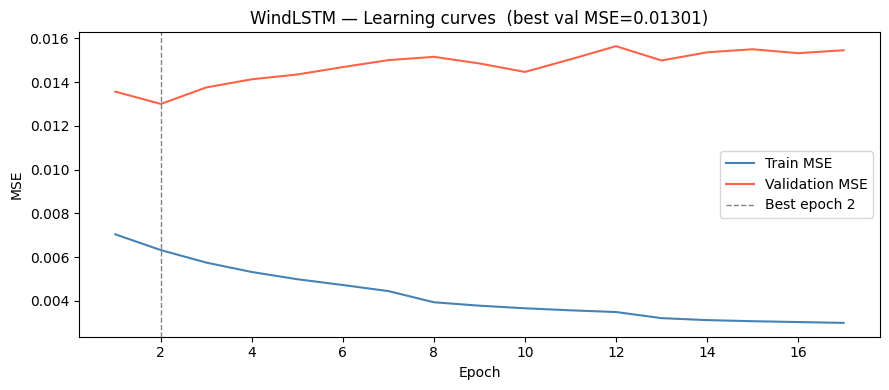

In [21]:
import matplotlib.pyplot as plt


def plot_learning_curves(history: dict, model_name: str = "Model"):
    """Plot train and validation MSE loss over epochs."""
    fig, ax = plt.subplots(figsize=(9, 4))
    epochs = range(1, len(history['train_loss']) + 1)
    ax.plot(epochs, history['train_loss'], label='Train MSE',      lw=1.5, color='steelblue')
    ax.plot(epochs, history['val_loss'],   label='Validation MSE', lw=1.5, color='tomato')
    best_ep  = int(np.argmin(history['val_loss'])) + 1
    best_val = min(history['val_loss'])
    ax.axvline(best_ep, ls='--', color='gray', lw=1, label=f'Best epoch {best_ep}')
    ax.set_title(f'{model_name} — Learning curves  (best val MSE={best_val:.5f})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_learning_curves(lstm_history, "WindLSTM")

In [22]:
def predict(model, loader, device=DEVICE):
    """Run inference on a DataLoader; returns (y_pred, y_true, site_ids) as numpy arrays."""
    model.eval()
    preds, trues, sites = [], [], []
    with torch.no_grad():
        for X_seq, site_id, y in loader:
            X_seq   = X_seq.to(device,   non_blocking=True)
            site_id = site_id.to(device, non_blocking=True)
            out = model(X_seq, site_id).squeeze(1).cpu().numpy()
            preds.append(out)
            trues.append(y.numpy())
            sites.append(site_id.cpu().numpy())
    return (
        np.concatenate(preds),
        np.concatenate(trues),
        np.concatenate(sites),
    )


# ── Test-set predictions ─────────────────────────────────────────────────────
lstm_pred, lstm_true, lstm_site_ids = predict(lstm_model, test_loader)

# Map integer site_ids back to names (aligned with test sequences)
lstm_site_names = np.array([site_mapping[s] for s in lstm_site_ids])

# ── Metrics ──────────────────────────────────────────────────────────────────
lstm_metrics, lstm_per_site = evaluate(
    lstm_true, lstm_pred,
    site_names = lstm_site_names,
    model_name = "WindLSTM",
)

[WindLSTM]  Global — MAE=0.0833  RMSE=0.1167  nRMSE=0.1178  (n=26,390)
                                     MAE    RMSE   nRMSE     n
site                                                          
Northwester 2                     0.1056  0.1389  0.1414  2639
Northwind                         0.0832  0.1184  0.1200  2639
Norther Offshore WP               0.0819  0.1163  0.1198  2639
Nobelwind Offshore Windpark       0.0796  0.1156  0.1170  2639
Seastar Offshore WP               0.0841  0.1155  0.1169  2639
Mermaid Offshore WP               0.0851  0.1153  0.1172  2639
Thorntonbank - C-Power - Area SW  0.0814  0.1153  0.1170  2639
Rentel Offshore WP                0.0800  0.1124  0.1134  2639
Thorntonbank - C-Power - Area NE  0.0783  0.1117  0.1141  2639
Belwind Phase 1                   0.0739  0.1051  0.1093  2639


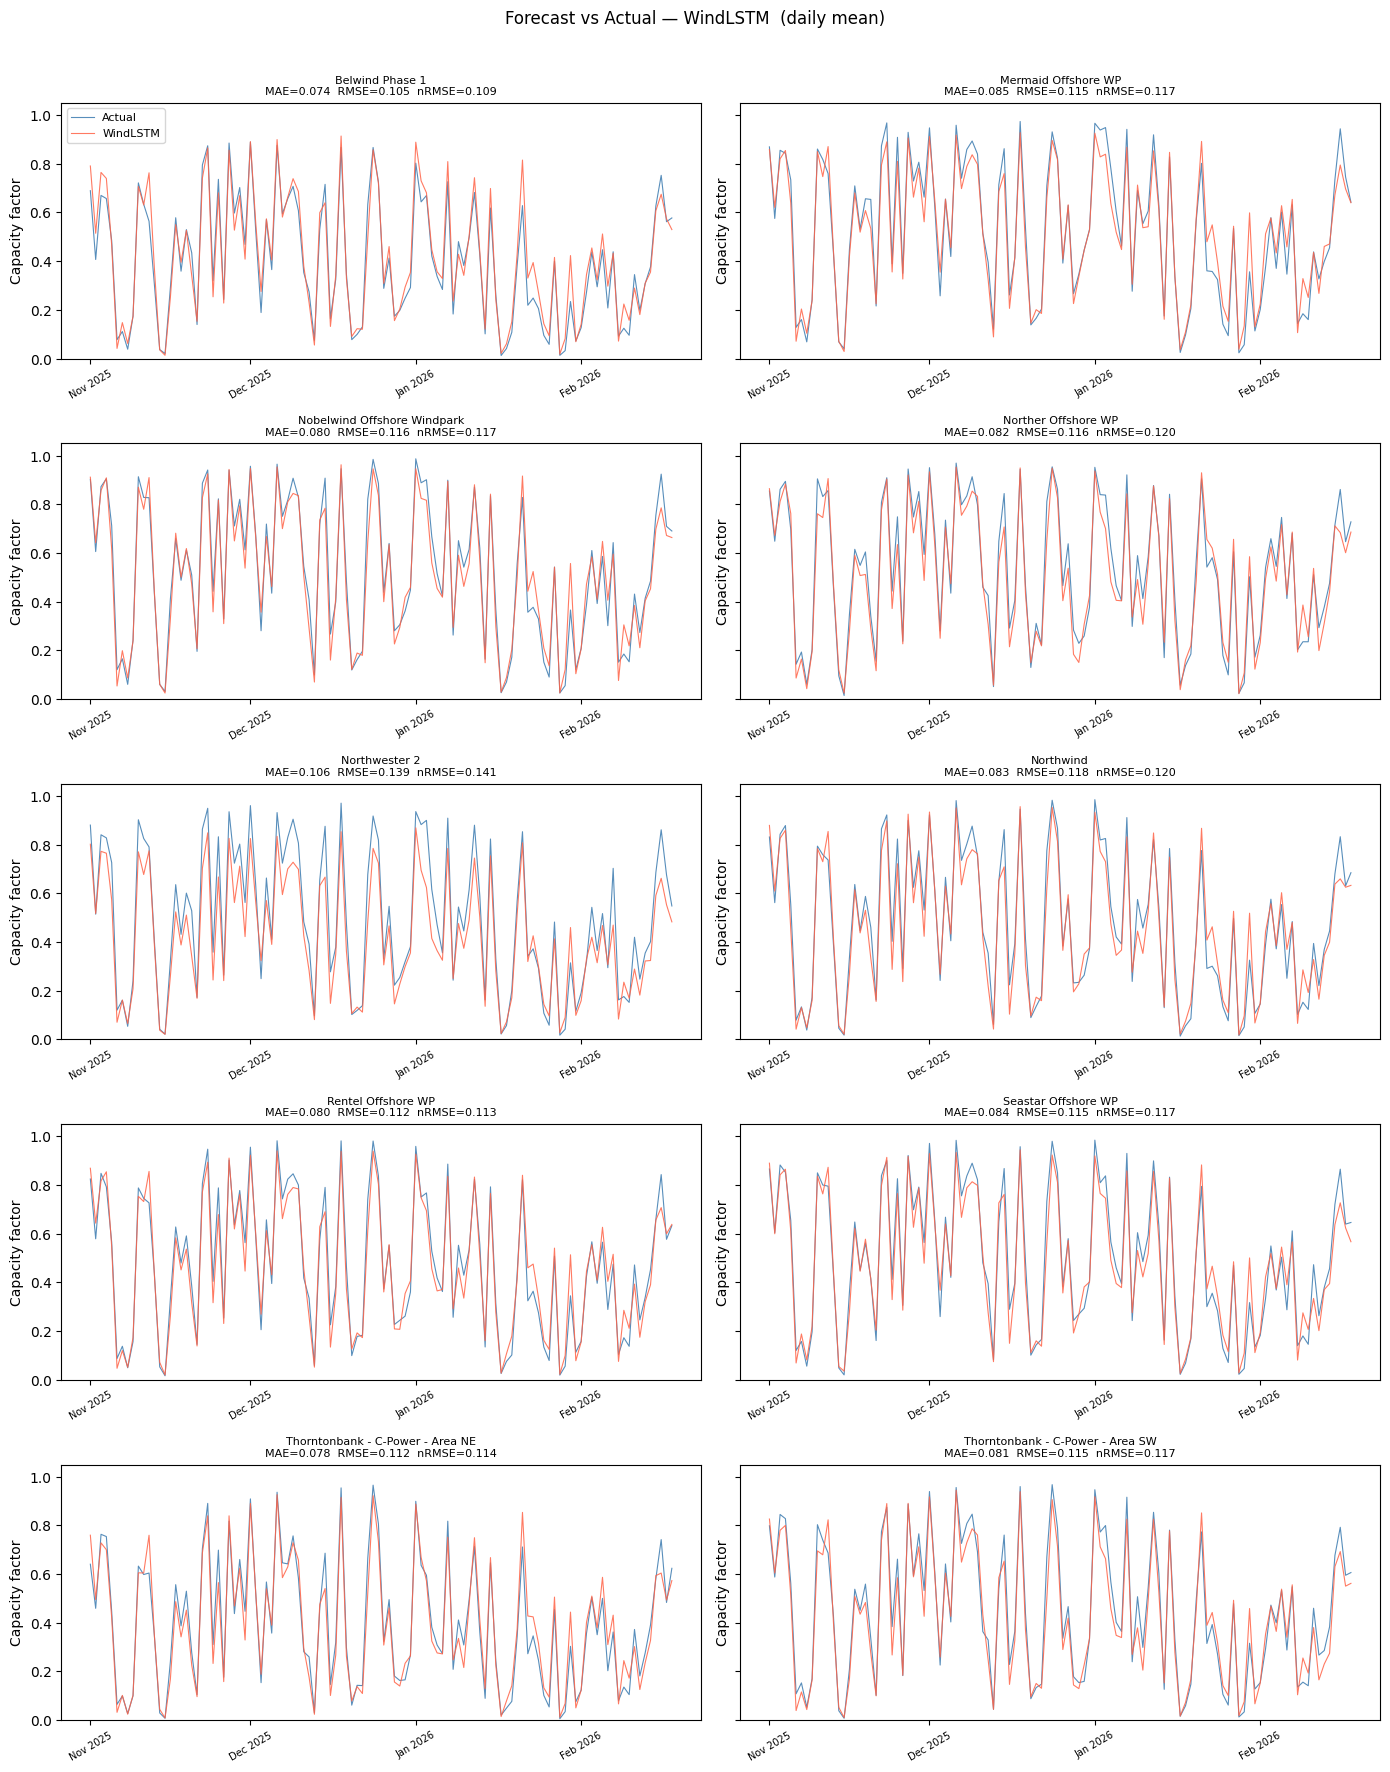

In [26]:
# Align delivery times with sequence order.
# build_sequences iterates np.unique(site_ids) in sorted order, so we must
# replicate that grouping to keep delivery_times[i] matched to pred[i].
_times = []
for sid in np.sort(np.unique(meta_test['site_id'].values)):
    mask = meta_test['site_id'].values == sid
    _times.append(meta_test['delivery_time'].values[mask])
lstm_delivery_times = np.concatenate(_times)

plot_forecast(
    delivery_times = lstm_delivery_times,
    y_true         = lstm_true,
    y_pred         = lstm_pred,
    site_names     = lstm_site_names,
    model_name     = "WindLSTM",
    resample       = 'D',   # daily mean — readable over the full ~3-month test window
)

In [27]:
from pathlib import Path

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

save_path = MODELS_DIR / 'lstm_wind.pt'
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'model_cfg':        LSTM_CFG,
    'feature_names':    FEATURE_NAMES,
    'site_mapping':     site_mapping,
    'val_mse':          min(lstm_history['val_loss']),
}, save_path)

print(f'LSTM model saved → {save_path}')

LSTM model saved → models\lstm_wind.pt
